# Credit-Based Loan Approval Prediction

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

## 2. Load Dataset

In [2]:
data = pd.read_csv("loan_approval_data.csv")

## 3. Explore the Dataset

In [3]:
data.head()
data.shape
data.describe()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

## 4. Data Cleaning

In [4]:
categorical_col = data.select_dtypes(include=["object"]).columns
num_col = data.select_dtypes(include=["number"]).columns

In [5]:
from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(strategy="mean") #transformer
data[num_col] = num_imp.fit_transform(data[num_col])

In [6]:
cat_imp = SimpleImputer(strategy="most_frequent")
data[categorical_col] = cat_imp.fit_transform(data[categorical_col])

## 5. Exploratory Data Analysis (EDA)

([<matplotlib.patches.Wedge at 0x202470e4d70>,
 [Text(-0.6521425375337495, 0.8858386482531919, 'Yes'),
  Text(0.6521428261765839, -0.8858384357581341, 'No')],
 [Text(-0.3557141113820451, 0.48318471722901374, '70.2'),
  Text(0.3557142688235912, -0.4831846013226186, '29.8')])

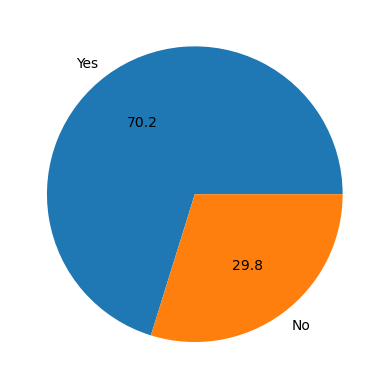

In [7]:
#how balanced are flag?

classes_count = data["Loan_Approved"].value_counts()
plt.pie(classes_count, labels=["Yes","No"], autopct="%1.1f")

<Axes: xlabel='Gender', ylabel='count'>

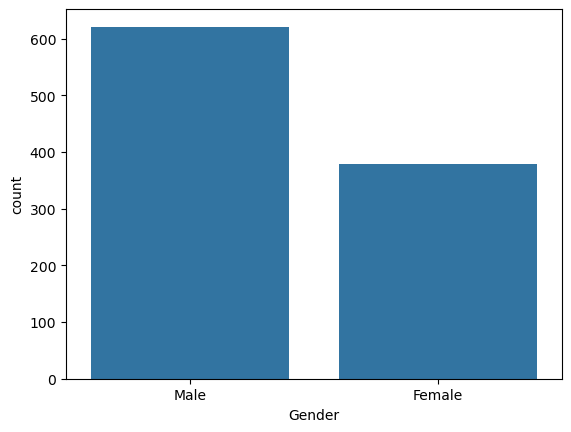

In [8]:
gender_cnt = data["Gender"].value_counts()
sns.barplot(gender_cnt)

## 6. Data Preprocessing

In [9]:
data = data.drop("Applicant_ID",axis=1)

In [10]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

le = LabelEncoder()

data["Education_Level"] = le.fit_transform(data["Education_Level"])
data["Loan_Approved"] = le.fit_transform(data["Loan_Approved"])


In [11]:
cols = ["Marital_Status","Loan_Purpose","Property_Area","Employment_Status","Gender","Employer_Category"]

ohe = OneHotEncoder(drop="first",sparse_output = False, handle_unknown = "ignore")

encoded = ohe.fit_transform(data[cols])

In [12]:
encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cols), index = data.index)

data = pd.concat([data.drop(columns=cols),encoded_df], axis=1)

# Correlation HeatMaps

In [13]:
num_cols = data.select_dtypes(include="number")
corr_matrix = num_cols.corr()

<Axes: >

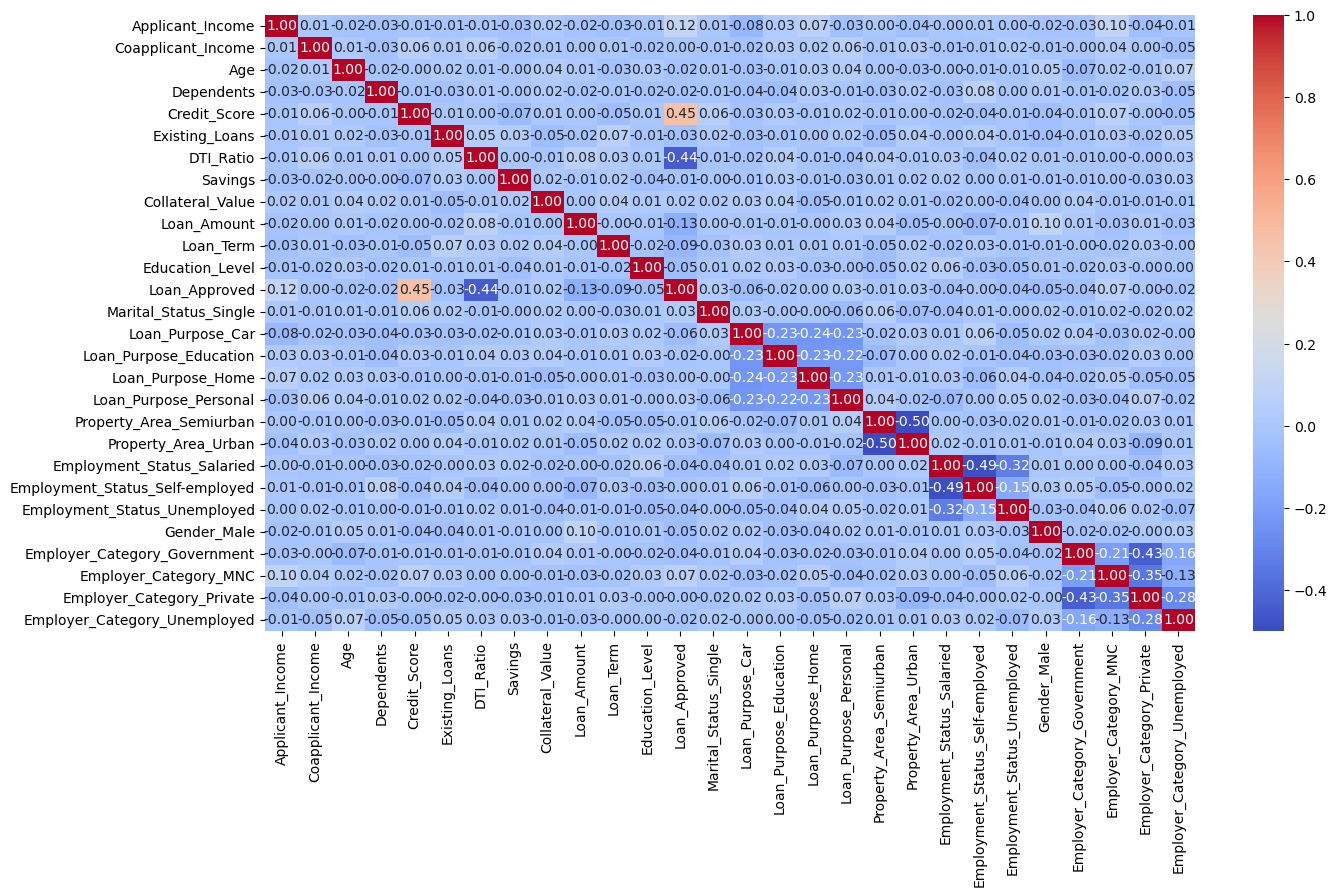

In [14]:
num_cols.corr()["Loan_Approved"].sort_values(ascending=False)
plt.figure(figsize = (15,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

## 7. Train_Test_split and Scaling

In [15]:
X = data.drop("Loan_Approved", axis=1)
y = data["Loan_Approved"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 8. Feature Engineering

In [46]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

In [21]:
# Add or Tranform features
data["DTI_Ratio_sq"] = data["DTI_Ratio"] ** 2
data["Credit_Score_sq"] = data["Credit_Score"] ** 2

# df["Applicant_Income_log"] = np.log1p(df["Applicant_Income"])

X = data.drop(columns=["Loan_Approved", "Credit_Score", "DTI_Ratio"])
y = data["Loan_Approved"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 9. Model Tranning and Evaluation

In [38]:
#Logistic Regression

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)

#Evalution

print("Logistic Regression:-")
log_acc = accuracy_score(y_test, log_pred)
log_precision = precision_score(y_test, log_pred)
log_recall = recall_score(y_test, log_pred)
log_f1 = f1_score(y_test, log_pred)
print("accuracy:", log_acc)

Logistic Regression:-
accuracy: 0.875


In [51]:
#KNN

knn_model = KNeighborsClassifier(n_neighbors=9)
knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)

#Evalution

print("K-Nearest Neighbors:- ")
knn_acc = accuracy_score(y_test, knn_pred)
knn_precision = precision_score(y_test, knn_pred)
knn_recall = recall_score(y_test, knn_pred)
knn_f1 = f1_score(y_test, knn_pred)
print("accuracy:", knn_acc)

K-Nearest Neighbors:- 
accuracy: 0.77


In [52]:
#Naive Bayes

nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

nb_pred = nb_model.predict(X_test_scaled)

#Evalution

print("Gaussian Naive Bayes:-")
nb_acc = accuracy_score(y_test, nb_pred)
nb_precision = precision_score(y_test, nb_pred)
nb_recall = recall_score(y_test, nb_pred)
nb_f1 = f1_score(y_test, nb_pred)
print("accuracy:", nb_acc)

Gaussian Naive Bayes:-
accuracy: 0.865


In [53]:
#Decision tree

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)
print("accuracy:", dt_acc)

accuracy: 0.9


## 10. Model Evaluation

In [54]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "K-Nearest Neighbors",
        "Gaussian Naive Bayes",
        "Decision Tree"
    ],
    "Accuracy": [log_acc, knn_acc, nb_acc, dt_acc],
    "Precision": [log_precision, knn_precision, nb_precision, dt_precision],
    "Recall": [log_recall, knn_recall, nb_recall, dt_recall],
    "F1 Score": [log_f1, knn_f1, nb_f1, dt_f1]
})

results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
3,Decision Tree,0.900,0.836066,0.836066,0.836066
0,Logistic Regression,0.875,0.790323,0.803279,0.796748
2,Gaussian Naive Bayes,0.865,0.783333,0.770492,0.776860
1,K-Nearest Neighbors,0.770,0.666667,0.491803,0.566038


## 11. Conclusion

In this project, I built a machine learning pipeline to predict loan approval using customer information. The dataset was cleaned, preprocessed, and analyzed before training multiple classification models. Feature engineering was also performed to evaluate its impact on model performance.

The models were compared based on their evaluation metrics, allowing the best-performing model to be identified. This project demonstrates the complete workflow of a supervised machine learning classification task, from data preprocessing to model evaluation.